In [1]:
import matplotlib.pyplot as plt
from dataclasses import dataclass
from __future__ import annotations
from typing import Generic, TypeVar
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
T = TypeVar("T")

@dataclass
class Vector3(Generic[T]):
    x: float
    y: float
    z: float

    @classmethod
    def from_vector3(cls, vec: Vector3) -> T:
        return cls(vec.x, vec.y, vec.z)

    def __init__(self, x: float = 0, y: float = 0, z: float = 0):
        self.x = x
        self.y = y
        self.z = z
    
    def __add__(self, other: T) -> T:
        return Vector3(self.x + other.x, self.y + other.y, self.z + other.z)

    def __mul__(self, s: float) -> Vector3:
        return Vector3(self.x*s, self.y*s, self.z*s)

    def __truediv__(self, s: float) -> Vector3:
        return Vector3(self.x/s, self.y/s, self.z/s)


class  Position(Vector3):
    pass

class Velocity(Vector3):
    pass

class Acceleration(Vector3):
    pass

class Force(Vector3):
    pass

In [3]:
class Body:

    def __init__(self, mass_kilograms: float, start_forces: list[Force], start_velocity: Velocity = Velocity(0, 0, 0), delta_time_milliseconds: float = 50):
        self.forces: list[Force] = start_forces
        self.forces_dict: dict[str, Force] = {}
        self.velocity: Velocity = start_velocity
        self.dt = delta_time_milliseconds / 1000
        self.m = mass_kilograms

    def add_force(self, name: str, force: Force) -> None:
        self.forces_dict[name] = (force, len(self.forces))
        self.forces.append(force)

    def rm_force(self, name: str) -> None:
        self.forces.pop(self.forces[name][1])
        del self.forces[name]

    def update_velocity(self) -> None:
        a = sum([f/self.m for f in self.forces], Acceleration(0, 0, 0))
        self.velocity += a*self.dt

In [4]:
class Constants:
    g = -9.81
    ticks_per_second = 20
    dt = 1000 / ticks_per_second
    m = 80

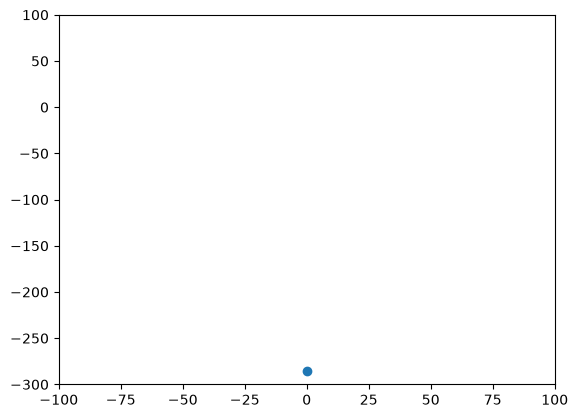

In [5]:
fig, ax = plt.subplots()

ax.set_xlim(-100, 100)
ax.set_ylim(-300, 100)

points = ax.scatter([], [])

body = Body(mass_kilograms=80, start_forces=[Force(y=Constants.g*Constants.m)], delta_time_milliseconds=Constants.dt)
position: Position = Position()

def update(frame):
    global position
    body.update_velocity()
    position = position + body.velocity*Constants.dt/1000

    points.set_offsets([[position.x, position.y]])

    return points,

anim = FuncAnimation(
    fig,
    update,
    frames=150,
    interval=Constants.dt
)


HTML(anim.to_jshtml())

In [7]:
from vpython import sphere, vector, rate

body = Body(
    mass_kilograms=80,
    start_forces=[Force(y=Constants.g * Constants.m)],
    delta_time_milliseconds=Constants.dt
)

position: Position = Position()

ball = sphere(
    pos=vector(position.x, position.y, position.z),
    radius=1
)

while True:
    rate(1000 / Constants.dt)

    body.update_velocity()

    position = position + body.velocity * Constants.dt / 1000

    ball.pos = vector(
        position.x,
        position.y,
        position.z
    )

/home/oedada/dev/Projects/experiments/paragliders/.venv/lib/python3.13/site-packages/vpython/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

KeyboardInterrupt: 